### Individual Homework

#### Enter your name here:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Analysis of movies IMDB dataset**

We will look at a ***subset*** sample of movies, taken from the [Kaggle IMDB 5000 movie dataset](https://www.kaggle.com/carolzhangdc/imdb-5000-movie-dataset)

In [2]:
movies = pd.read_csv('../Data/movies.csv')
movies

,title,genre,director,year,duration,gross,budget,cast_facebook_likes,votes,reviews,rating
0,Avatar,Action,James Cameron,2009,178,760505847,237000000,4834,886204,3777,7.9
1,Titanic,Drama,James Cameron,1997,194,658672302,200000000,45223,793059,2843,7.7
2,Jurassic World,Action,Colin Trevorrow,2015,124,652177271,150000000,8458,418214,1934,7.0
3,The Avengers,Action,Joss Whedon,2012,173,623279547,220000000,87697,995415,2425,8.1
4,The Dark Knight,Action,Christopher Nolan,2008,152,533316061,185000000,57802,1676169,5312,9.0
...,...,...,...,...,...,...,...,...,...,...,...
2956,Locker 13,Thriller,Bruce Dellis,2014,95,2468,300000,2048,241,15,4.8
2957,The Ghastly Love of Johnny X,Comedy,Paul Bunnell,2012,106,2436,2000000,1611,344,113,5.7
2958,Detention of the Dead,Comedy,Alex Craig Mann,2012,87,1332,500000,2251,2038,49,4.6
2959,The Trials of Darryl Hunt,Crime,Ricki Stern,2006,106,1111,200000,2,771,21,7.7


Besides the obvious variables of `title`, `genre`, `director`, `year`, and `duration`, the rest of the variables are as follows:

-   `gross` : The gross earnings in the US box office, not adjusted for inflation
-   `budget`: The movie's budget
-   `cast_facebook_likes`: the number of facebook likes cast memebrs received
-   `votes`: the number of people who voted for (or rated) the movie in IMDB
-   `reviews`: the number of reviews for that movie
-   `rating`: IMDB average rating

**Produce a table with the count of movies by genre, ranked in descending order**


In [3]:
movies.groupby("genre").size().sort_values(ascending=False)

genre
Comedy         848
Action         738
Drama          498
Adventure      288
Crime          202
Biography      135
Horror         131
Animation       35
Fantasy         28
Documentary     25
Mystery         16
Sci-Fi           7
Family           3
Musical          2
Romance          2
Western          2
Thriller         1
dtype: int64

**Produce a table with the average gross earning and budget (`gross` and `budget`) by genre. Calculate a variable `return_on_budget` which shows how many \$ did a movie make at the box office for each \$ of its budget. Ranked genres by this `return_on_budget` in descending order**

In [4]:
movies["return_on_budget"] = movies["gross"]/movies["budget"]
genre_analysis = movies.groupby("genre")[["gross", "budget", "return_on_budget"]].mean()

genre_analysis = genre_analysis.sort_values(
    "return_on_budget",
    ascending=False
)

genre_analysis

,gross,budget,return_on_budget
genre,,,
Horror,3.771374e+07,1.350492e+07,88.304785
Biography,4.520181e+07,2.854370e+07,22.280597
Musical,9.208400e+07,3.189500e+06,18.817819
Family,1.491605e+08,1.483333e+07,14.076490
Documentary,1.735397e+07,5.887852e+06,8.698550
Western,2.082188e+07,3.465000e+06,7.062800
Fantasy,4.240884e+07,1.758214e+07,6.681969
Animation,9.843379e+07,6.170143e+07,5.009095
Comedy,4.263055e+07,2.444632e+07,3.713990


**Produce a table that shows the top 15 directors who have created the highest gross revenue in the box office. Don't just show the total gross amount, but also the mean, median, and standard deviation per director**

In [5]:
director_analysis = movies.groupby("director")["gross"].agg(
    total_gross="sum",
    mean_gross="mean",
    median_gross="median",
    std_gross="std"
)

director_analysis = director_analysis.sort_values(
    "total_gross",
    ascending=False
).head(15)

director_analysis

,total_gross,mean_gross,median_gross,std_gross
director,,,,
Steven Spielberg,4014061704,1.745244e+08,164435221.0,1.014211e+08
Michael Bay,2231242537,1.716340e+08,138396624.0,1.271616e+08
Tim Burton,2071275480,1.294547e+08,76519172.0,1.087269e+08
Sam Raimi,2014600898,2.014601e+08,234903076.0,1.621266e+08
James Cameron,1909725910,3.182877e+08,175562880.5,3.091713e+08
Christopher Nolan,1813227576,2.266534e+08,196667606.5,1.872241e+08
George Lucas,1741418480,3.482837e+08,380262555.0,1.461939e+08
Robert Zemeckis,1619309108,1.245622e+08,100853835.0,9.130028e+07
Clint Eastwood,1378321100,7.254322e+07,46700000.0,7.548741e+07


**Produce a table that describes how ratings are distributed by genre. We don't want just the mean, but also, min, max, median, SD and some kind of a histogram or density graph that visually shows how ratings are distributed.**

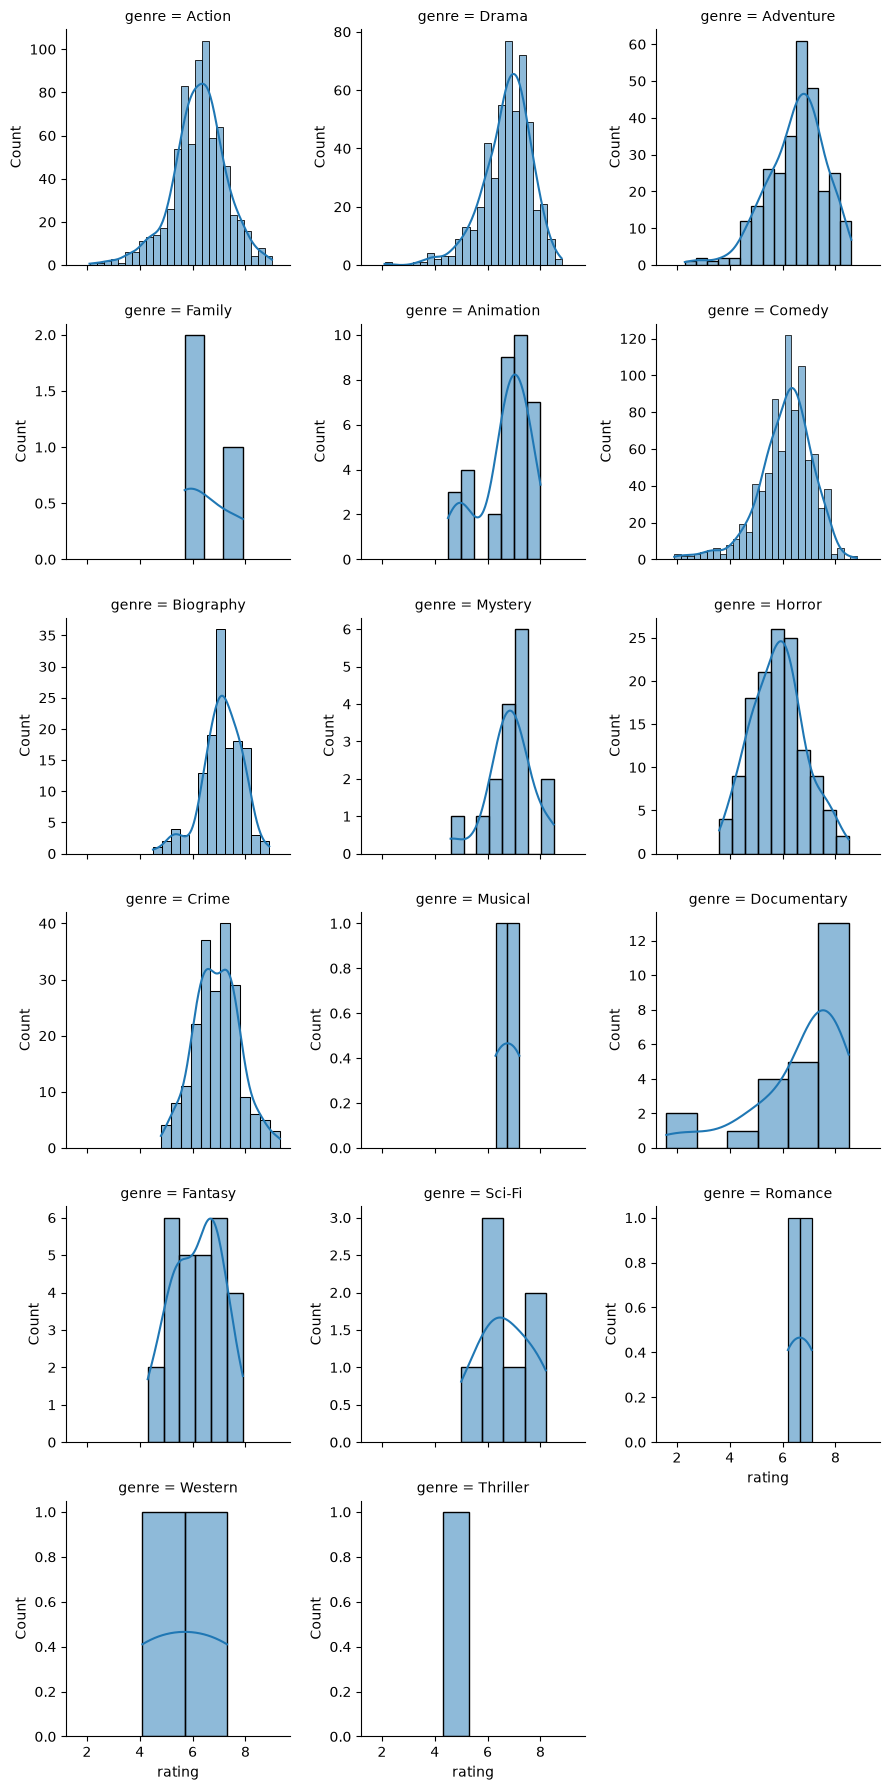

In [6]:
rating_analysis = movies.groupby("genre")["rating"].agg(
    mean="mean",
    min="min",
    max="max",
    median="median",
    std="std"
)

rating_analysis

g = sns.FacetGrid(
    movies,
    col="genre",
    col_wrap=3,
    sharey=False
)

g.map_dataframe(
    sns.histplot,
    x="rating",
    kde=True
)

plt.show()

**Challenge - Produce a table of your own choosing, something you think is important/interesting to have data for, justify your result by writting a 2 sentence explanation/interpretation of the result.**

In [7]:
year_analysis = movies.groupby("year").agg(
    number_of_movies=("title", "count"),
    average_rating=("rating", "mean")
).sort_values("number_of_movies", ascending=False)

year_analysis.head(15)

,number_of_movies,average_rating
year,,
2009,141,6.271631
2001,139,6.173381
2002,139,6.188489
2008,139,6.230935
2010,136,6.288235
2004,134,6.355224
2006,133,6.235338
2012,132,6.403788
2005,130,6.373077


The table shows how many movies were released in each year and their average IMDb rating. This is useful for understanding differences in movie production and average ratings across years.

#### Use visualisation to answer the following questions

**Examine the relationship between `gross` and `cast_facebook_likes`. Produce a scatterplot and write one sentence discussing whether the number of facebook likes that the cast has received is likely to be a good predictor of how much money a movie will make at the box office. What variable are you going to map to the Y- and X- axes?**

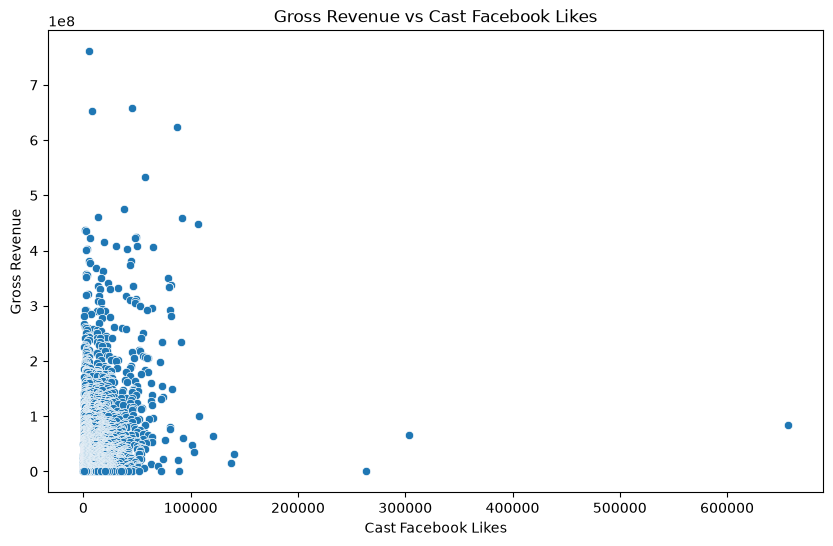

In [8]:
plot_data = movies[["cast_facebook_likes", "gross"]].dropna()

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=plot_data,
    x="cast_facebook_likes",
    y="gross"
)

plt.title("Gross Revenue vs Cast Facebook Likes")
plt.xlabel("Cast Facebook Likes")
plt.ylabel("Gross Revenue")
plt.show()

**Examine the relationship between `gross` and `budget`. Produce a scatterplot and write one sentence discussing whether budget is likely to be a good predictor of how much money a movie will make at the box office.**

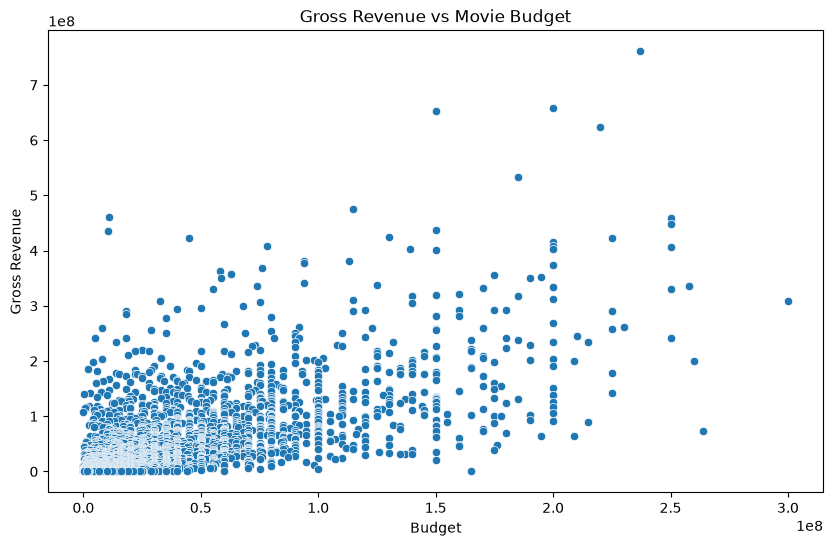

In [9]:
budget_data = movies[["budget", "gross"]].dropna()

plt.figure(figsize=(10, 6))

sns.scatterplot(

    data=budget_data,

    x="budget",

    y="gross"

)

plt.title("Gross Revenue vs Movie Budget")

plt.xlabel("Budget")

plt.ylabel("Gross Revenue")

plt.show()

The scatterplot suggests that movies with higher budgets tend to have higher gross revenue, although budget alone is not a perfect predictor of box-office revenue.

**Examine the relationship between `gross` and `rating`. Produce a scatterplot, faceted by `genre` and discuss whether IMDB ratings are likely to be a good predictor of how much money a movie will make at the box office. Is there anything strange in this dataset?**

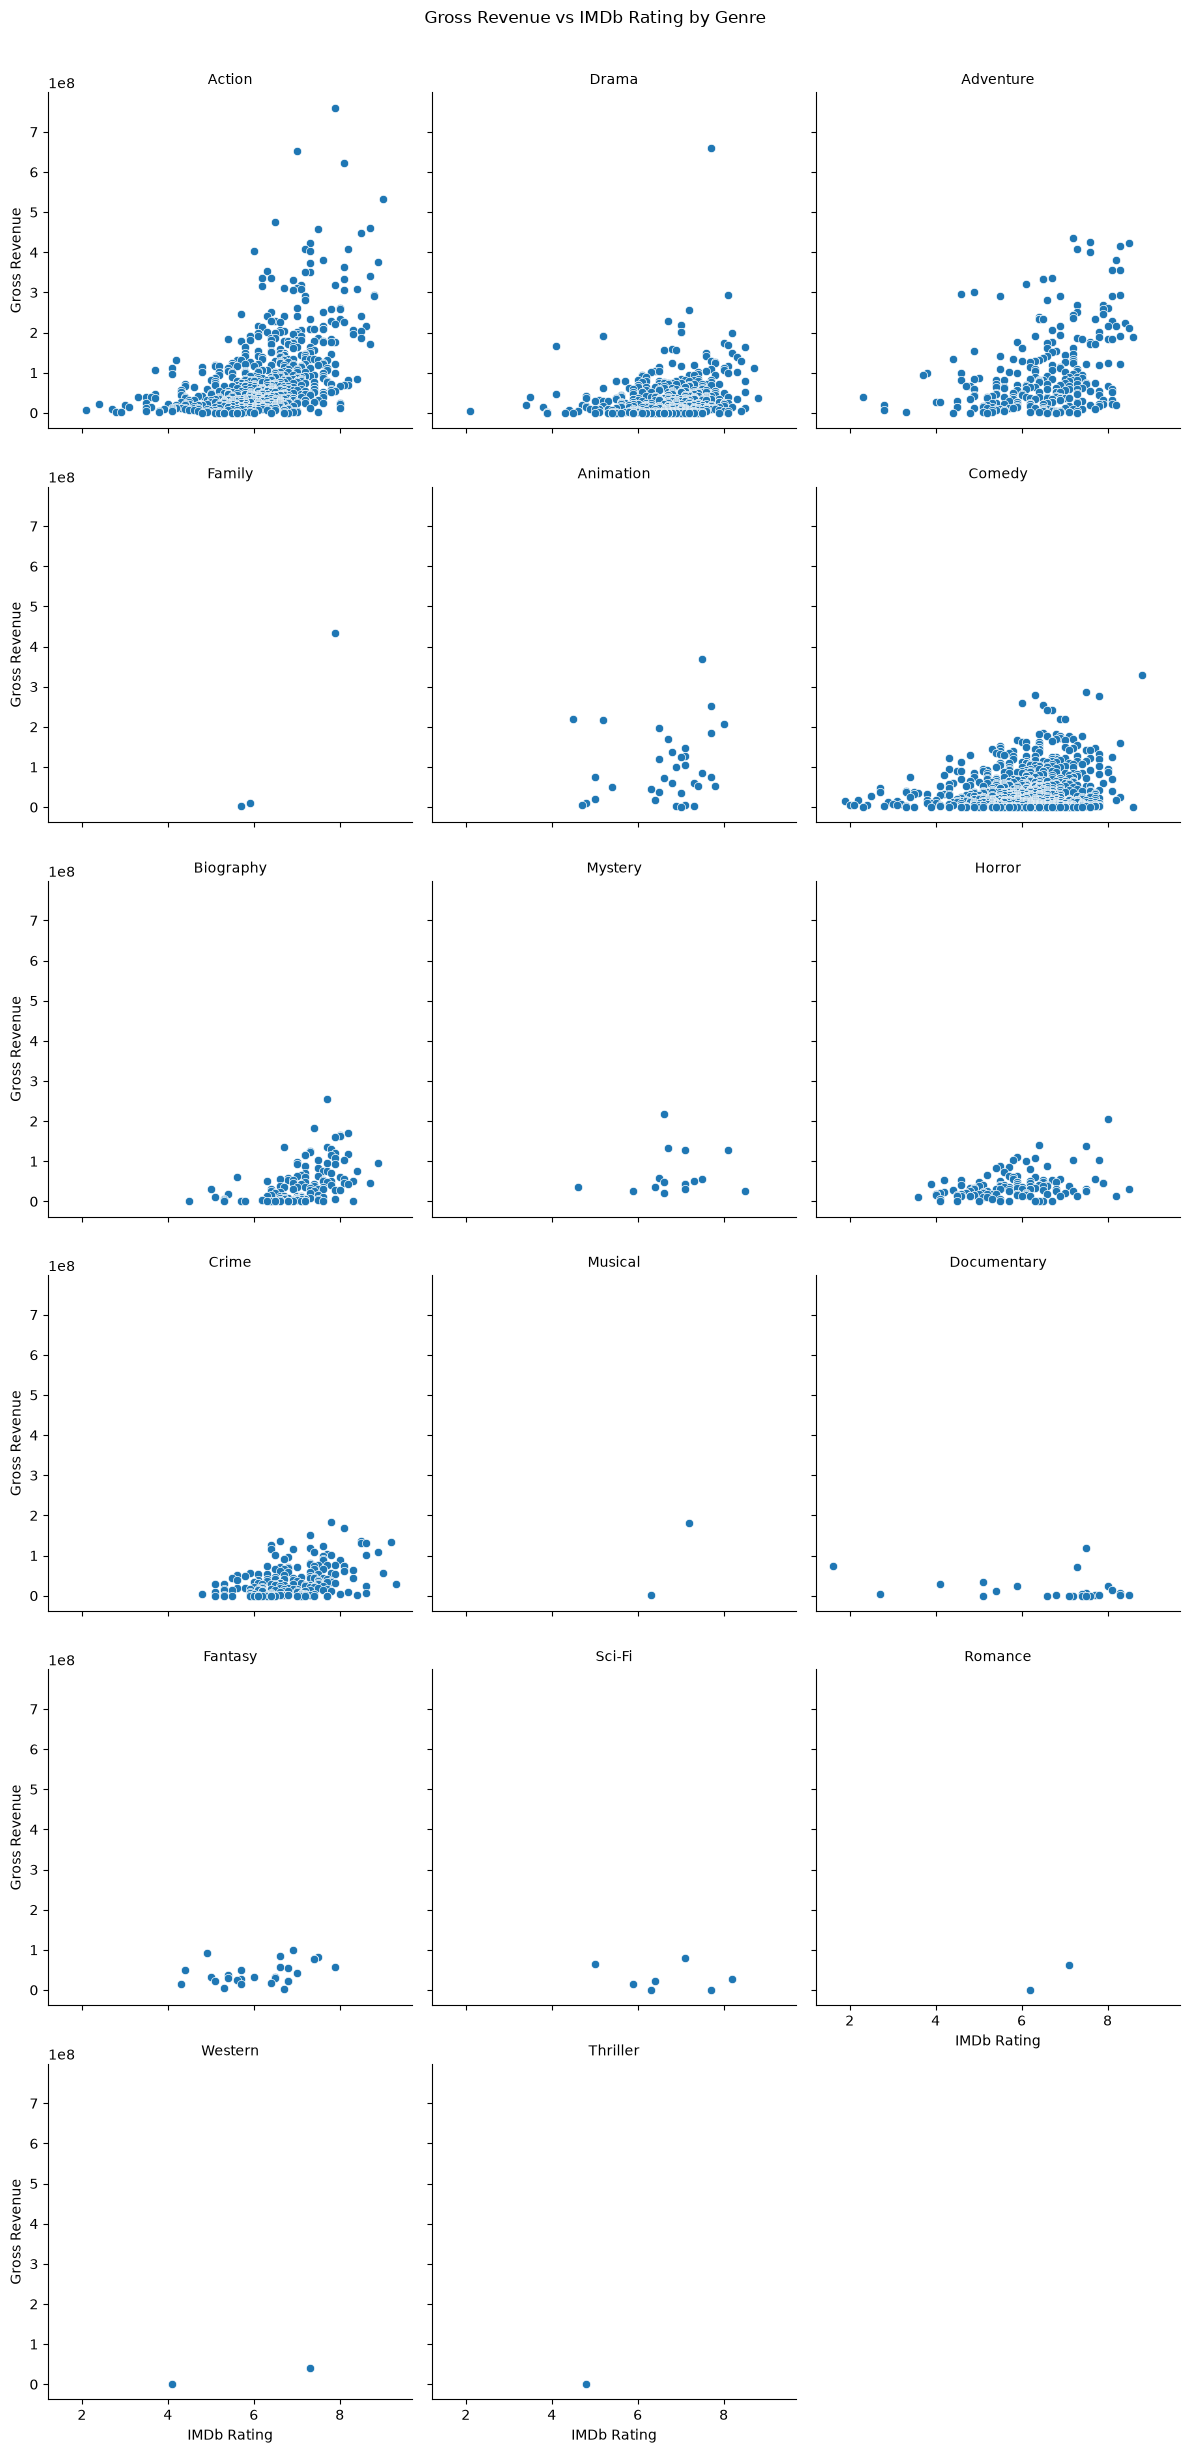

In [10]:
rating_data = movies[["gross", "rating", "genre"]].dropna()

g = sns.FacetGrid(

    rating_data,

    col="genre",

    col_wrap=3,

    height=4

)

g.map_dataframe(

    sns.scatterplot,

    x="rating",

    y="gross"

)

g.set_axis_labels("IMDb Rating", "Gross Revenue")

g.set_titles("{col_name}")

g.fig.suptitle("Gross Revenue vs IMDb Rating by Genre", y=1.02)

plt.show()

The plots show that IMDb rating does not have a consistently strong relationship with gross revenue across all genres. A notable feature of the dataset is that some genres contain relatively few observations, making comparisons less reliable.

**Challenge - Produce a visualisation of your choosing, something you think is important to explore/investigate visually. Do make it a comprehensive graph and not a single histogram or density plot. Make it publication ready, label your axes, give it a title, choose colouring options, appropirately formatted text etc.**

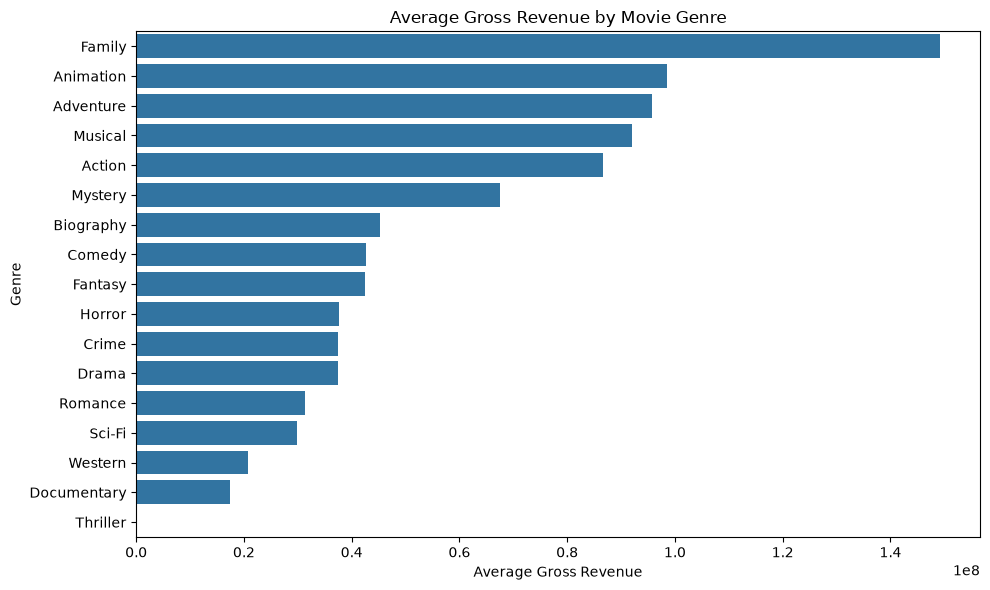

In [11]:
genre_gross = (

    movies.groupby("genre")["gross"]

    .mean()

    .sort_values(ascending=False)

)

plt.figure(figsize=(10, 6))

sns.barplot(

    x=genre_gross.values,

    y=genre_gross.index

)

plt.title("Average Gross Revenue by Movie Genre")

plt.xlabel("Average Gross Revenue")

plt.ylabel("Genre")

plt.tight_layout()

plt.show()

### Deliverables

Poduce a clean, stand-alone notebook (or HTML export) with:

All tables/plots properly labeled

Brief interpretations where requested

Upload final HTML/Notebook.